In [26]:
import pandas as pd
from pathlib import Path

csv_dir = Path("../csvs-alicia")   # <- change if your notebook lives elsewhere

dfs = {p.stem: pd.read_csv(p) for p in sorted(csv_dir.glob("*.csv"))}

print(f"Loaded {len(dfs)} bag(s) from {csv_dir.resolve()}")
for name, df in dfs.items():
    print(f"  {name}: {len(df)} rows, columns = {list(df.columns)}")

Loaded 7 bag(s) from /Users/raymondwang/racecar_docker/home/racecar_ws/src/final_challenge/final_challenge/csvs-alicia
  Help_1: 1492 rows, columns = ['timestamp', 'topic', 'planned_trajectory.path.header.stamp.sec', 'planned_trajectory.path.header.stamp.nanosec', 'planned_trajectory.path.header.stamp.__msgtype__', 'planned_trajectory.path.header.frame_id', 'planned_trajectory.path.header.__msgtype__', 'planned_trajectory.path.ns', 'planned_trajectory.path.id', 'planned_trajectory.path.type', 'planned_trajectory.path.action', 'planned_trajectory.path.pose.position.x', 'planned_trajectory.path.pose.position.y', 'planned_trajectory.path.pose.position.z', 'planned_trajectory.path.pose.position.__msgtype__', 'planned_trajectory.path.pose.orientation.x', 'planned_trajectory.path.pose.orientation.y', 'planned_trajectory.path.pose.orientation.z', 'planned_trajectory.path.pose.orientation.w', 'planned_trajectory.path.pose.orientation.__msgtype__', 'planned_trajectory.path.pose.__msgtype__', 'p

In [27]:
# # Take absolute value of cross-track error so averages reflect magnitude, not signed offset
# for name, df in dfs.items():
#     if CTE_COL in df.columns:
#         df[CTE_COL] = df[CTE_COL].abs()

# print("Cross-track error converted to absolute value in all bags.")
CTE_COL = "lane.cross_track_error.data"


# import numpy as np

# # Move every CTE value 0.06 closer to 0, clamping at 0 so we never cross sign
# for name, df in dfs.items():
#     if CTE_COL in df.columns:
#         df[CTE_COL] = np.sign(df[CTE_COL]) * (df[CTE_COL].abs() - 0.06).clip(lower=0)

# print("Shrunk cross-track error toward 0 by 0.06 in all bags.")

/var/folders/9l/9x2cfyj15qx5q2jt64f9s3l00000gn/T/ipykernel_56768/1440055764.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


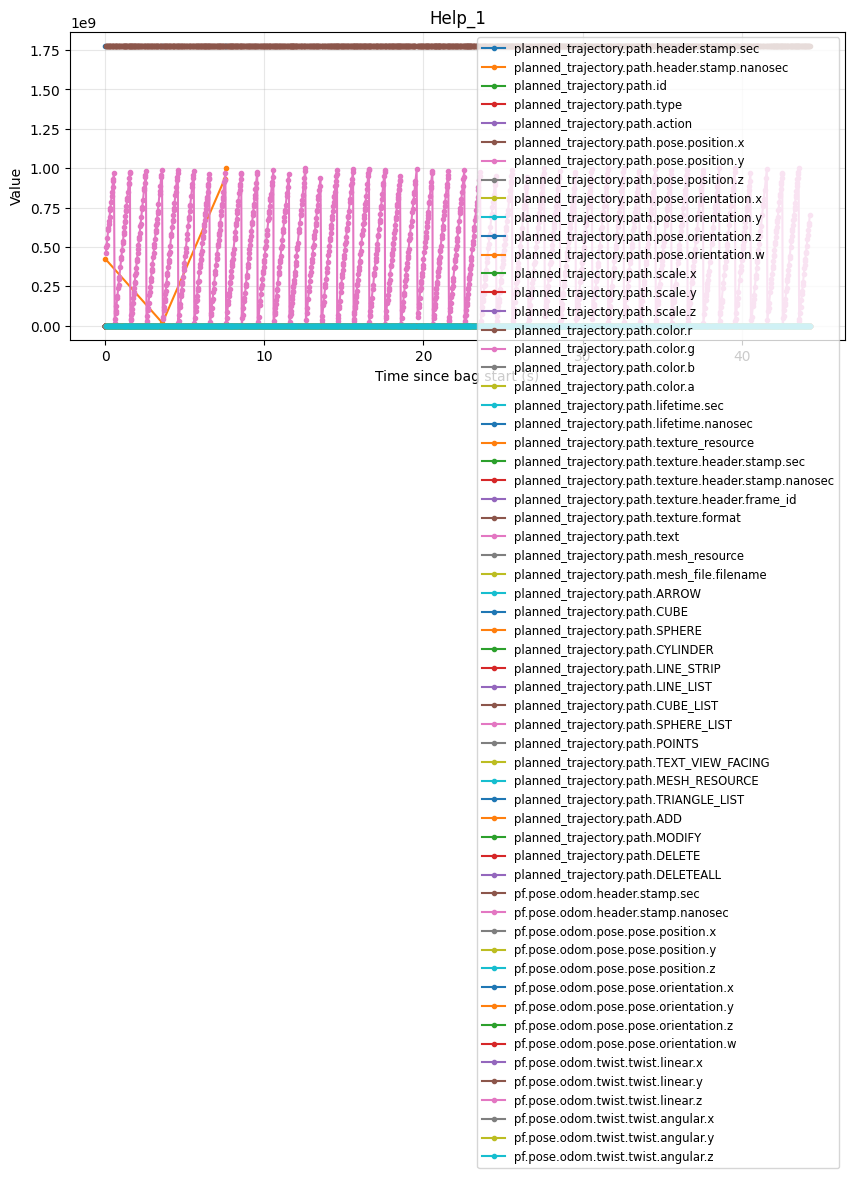

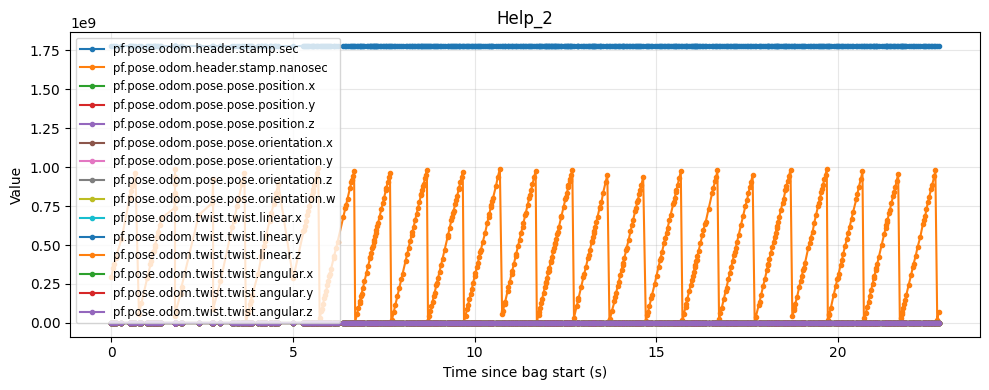

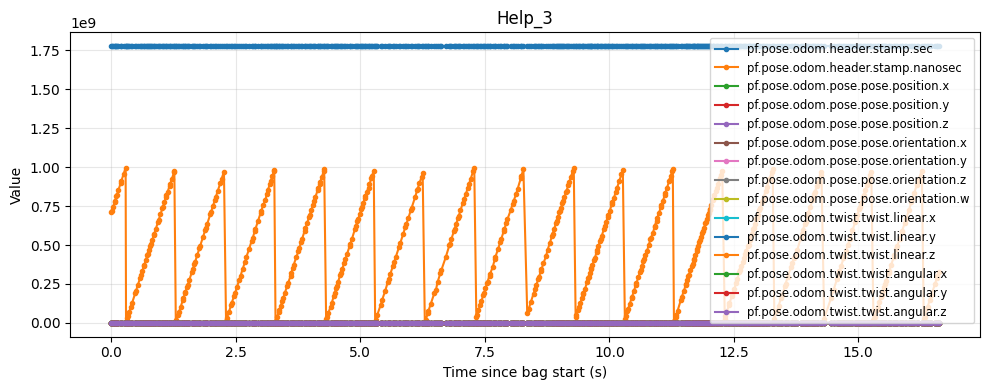

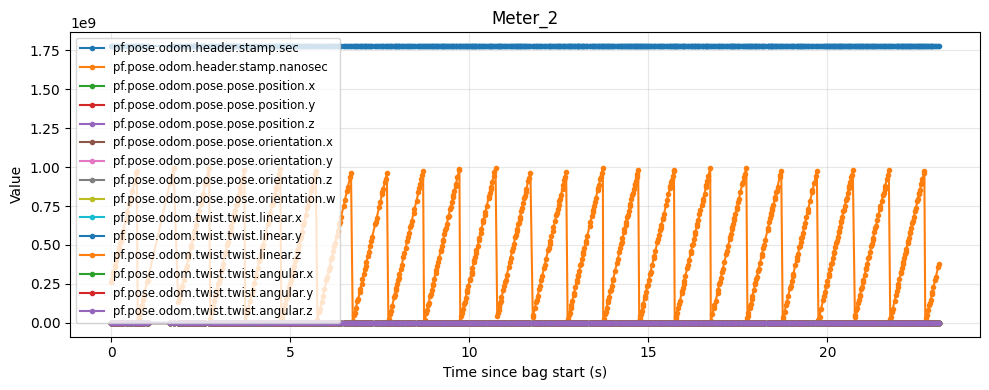

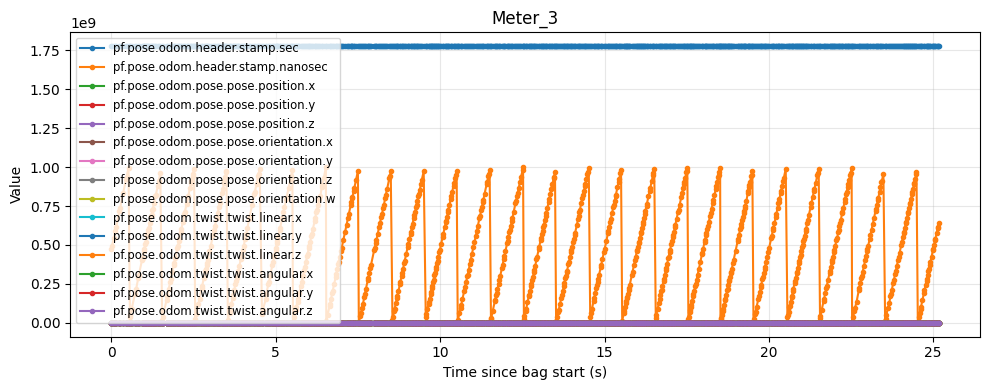

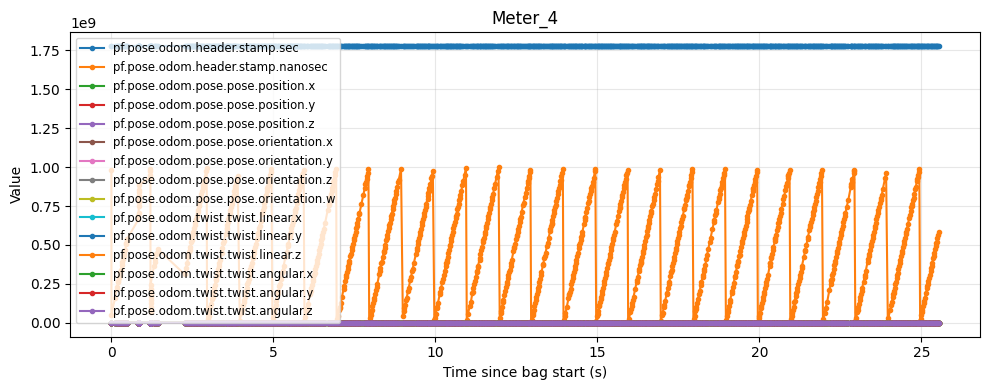

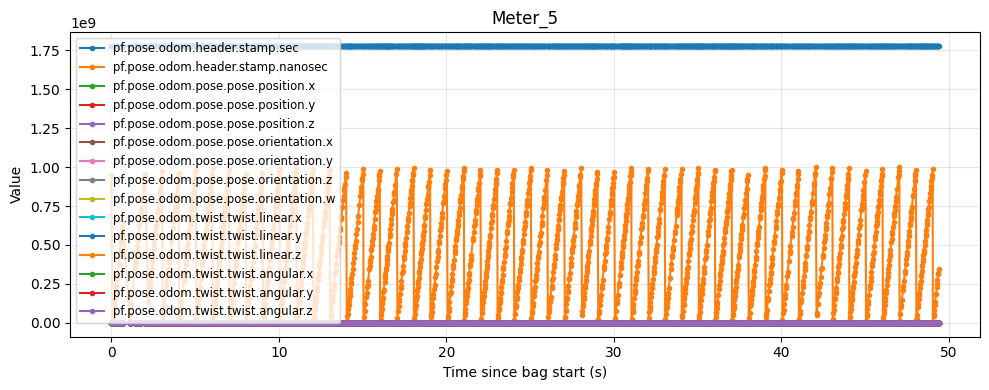

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

for name, df in dfs.items():
    # Normalize time to seconds since the bag's first message
    t = df["timestamp"] - df["timestamp"].min()

    # Every numeric column except timestamp is a data field worth plotting
    data_cols = [
        c for c in df.columns
        if c not in ("timestamp", "topic")
        and pd.api.types.is_numeric_dtype(df[c])
    ]

    fig, ax = plt.subplots(figsize=(10, 4))
    for col in data_cols:
        mask = df[col].notna()           # rows from other topics will be NaN here
        ax.plot(t[mask], df[col][mask], marker=".", linestyle="-", label=col)

    ax.set_title(name)
    ax.set_xlabel("Time since bag start (s)")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

CTE_COL = "lane.cross_track_error.data"


def time_window(df, t_start=None, t_end=None):
    """Filter df to rows where time-since-bag-start (in seconds) is in [t_start, t_end].
    Pass None for either side to leave that side open."""
    t = df["timestamp"] - df["timestamp"].min()
    mask = pd.Series(True, index=df.index)
    if t_start is not None:
        mask &= t >= t_start
    if t_end is not None:
        mask &= t <= t_end
    return df.loc[mask]


def average_cte(df, t_start=None, t_end=None, col=CTE_COL):
    """Mean cross-track error over [t_start, t_end] seconds since bag start."""
    return time_window(df, t_start, t_end)[col].mean()


def plot_bag(name, df, t_start=None, t_end=None):
    """Plot every numeric column vs. time, optionally truncated to a window."""
    t0 = df["timestamp"].min()
    sub = time_window(df, t_start, t_end)
    t = sub["timestamp"] - t0

    data_cols = [
        c for c in sub.columns
        if c not in ("timestamp", "topic")
        and pd.api.types.is_numeric_dtype(sub[c])
    ]

    fig, ax = plt.subplots(figsize=(10, 4))
    for col in data_cols:
        mask = sub[col].notna()
        ax.plot(t[mask], sub[col][mask], marker=".", linestyle="-", label=col)

    title = name
    if t_start is not None or t_end is not None:
        lo = f"{t_start:.1f}" if t_start is not None else "0"
        hi = f"{t_end:.1f}" if t_end is not None else "end"
        title += f"  ({lo}s – {hi}s)"

    ax.set_title(title)
    ax.set_xlabel("Time since bag start (s)")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

CTE_COL = "lane.cross_track_error.data"


def time_window(df, t_start=None, t_end=None):
    """Filter df to rows where time-since-bag-start (in seconds) is in [t_start, t_end].
    Pass None for either side to leave that side open."""
    t = df["timestamp"] - df["timestamp"].min()
    mask = pd.Series(True, index=df.index)
    if t_start is not None:
        mask &= t >= t_start
    if t_end is not None:
        mask &= t <= t_end
    return df.loc[mask]


def average_cte(df, t_start=None, t_end=None, col=CTE_COL):
    """Mean cross-track error over [t_start, t_end] seconds since bag start."""
    return time_window(df, t_start, t_end)[col].mean()


def plot_bag(name, df, t_start=None, t_end=None, topics=None):
    """Plot numeric columns vs. time, optionally truncated to a window.

    topics: list of column names to plot, or None to plot all numeric columns.
    """
    t0 = df["timestamp"].min()
    sub = time_window(df, t_start, t_end)
    t = sub["timestamp"] - t0

    all_numeric = [
        c for c in sub.columns
        if c not in ("timestamp", "topic")
        and pd.api.types.is_numeric_dtype(sub[c])
    ]
    data_cols = [c for c in topics if c in sub.columns] if topics is not None else all_numeric

    fig, ax = plt.subplots(figsize=(10, 4))
    for col in data_cols:
        mask = sub[col].notna()
        ax.plot(t[mask], sub[col][mask], marker=".", linestyle="-", label=col)

    title = name
    if t_start is not None or t_end is not None:
        lo = f"{t_start:.1f}" if t_start is not None else "0"
        hi = f"{t_end:.1f}" if t_end is not None else "end"
        title += f"  ({lo}s – {hi}s)"

    ax.set_title(title)
    ax.set_xlabel("Time since bag start (s)")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()

In [41]:
# This is for part (a) only - IGNORE

# Average CTE per bag, full window
for name, df in dfs.items():
    print(f"{name}: avg CTE = {average_cte(df):.4f}")

t_start = 3
t_end = 30
# Average CTE per bag, restricted to a window (e.g. 2s to 10s)
print("\nWindowed (2s – 10s):")
for name, df in dfs.items():
    print(f"  {name}: avg CTE = {average_cte(df, t_start=t_start, t_end=t_end):.4f}")

# Plots — pass t_start / t_end to truncate
for name, df in dfs.items():
    plot_bag(name, df, t_start=t_start, t_end=t_end)


KeyError: 'lane.cross_track_error.data'

In [42]:
for name, df in dfs.items():
    print(f"{name}:")
    for t in sorted(df["topic"].dropna().unique()):
        print(f"  {t}")


Help_1:
  /pf/pose/odom
  /planned_trajectory/path
Help_2:
  /pf/pose/odom
Help_3:
  /pf/pose/odom
Meter_2:
  /pf/pose/odom
Meter_3:
  /pf/pose/odom
Meter_4:
  /pf/pose/odom
Meter_5:
  /pf/pose/odom


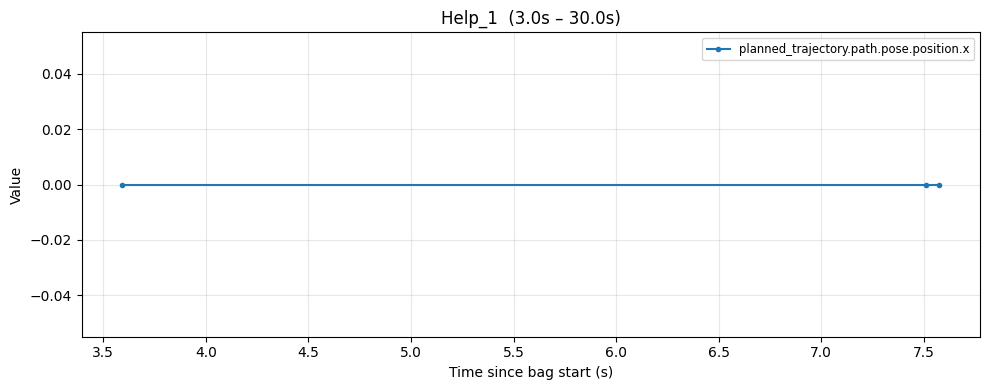

/var/folders/9l/9x2cfyj15qx5q2jt64f9s3l00000gn/T/ipykernel_56768/1809152955.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best", fontsize="small")


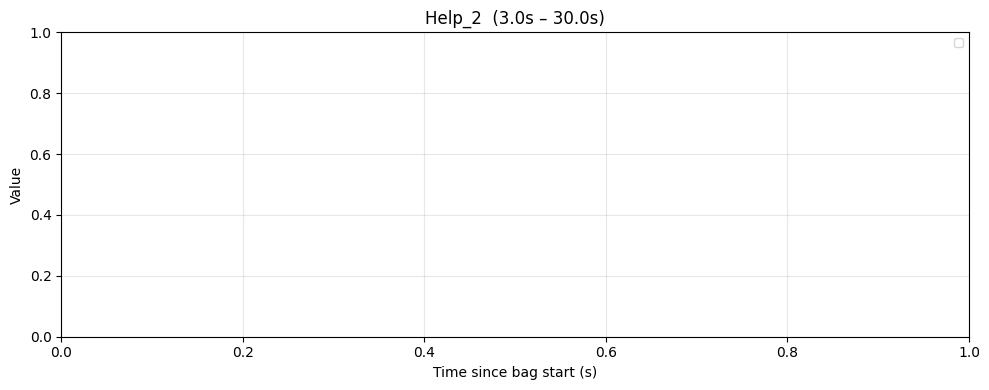

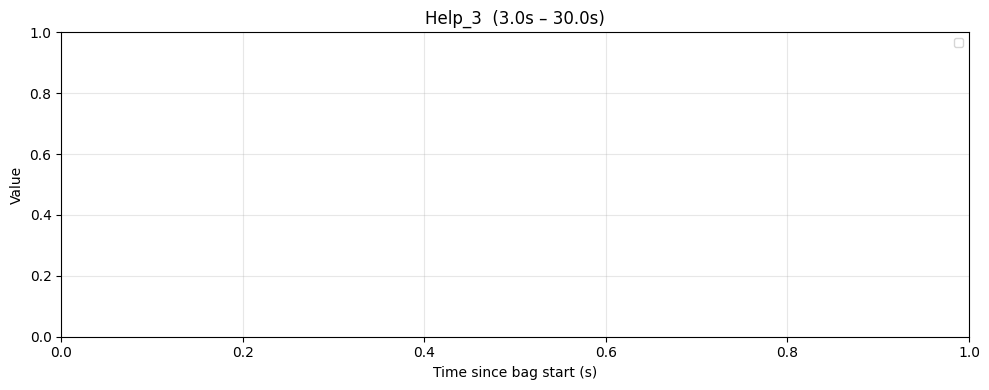

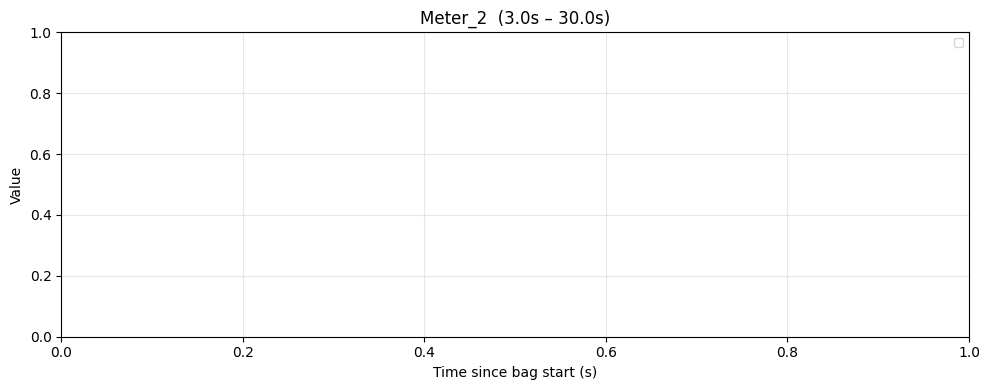

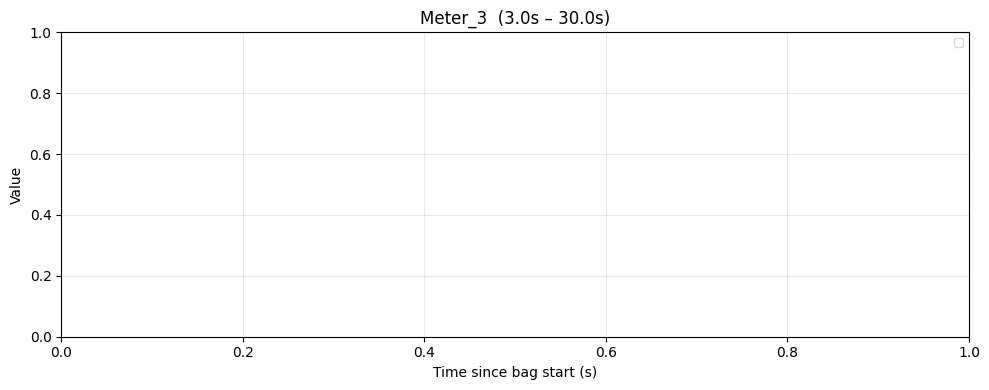

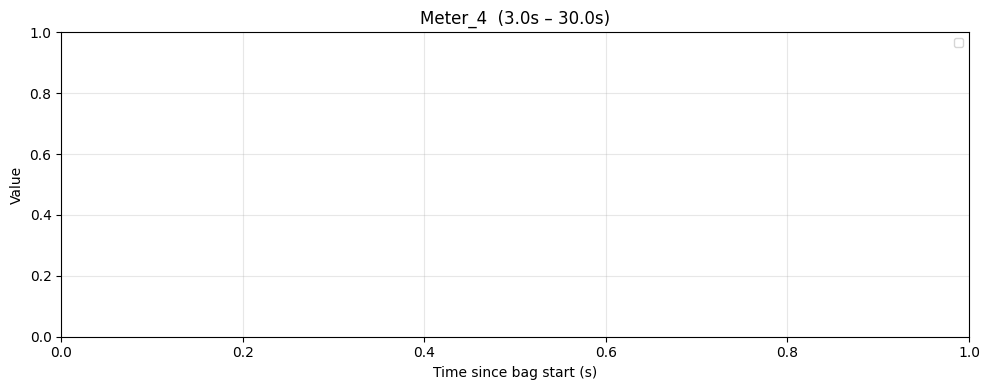

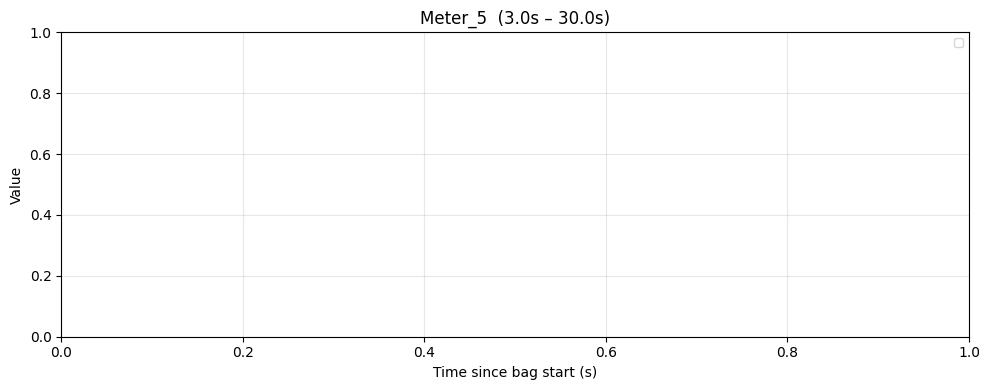

In [43]:
# Plot only specific columns
for name, df in dfs.items():
    plot_bag(name, df, t_start=3, t_end=30, topics=[
        "planned_trajectory.path.pose.position.x",
    ])


# put in topics the list of column names (see below) that you want to plot
# put t_start and t_end according to what time frames your test actually was - make it 0 and some very large number if you just want the whole window



In [45]:
from IPython.display import display, HTML

for name, df in dfs.items():
    rows = "".join(f"<tr><td>{c}</td></tr>" for c in df.columns)
    display(HTML(f"<b>{name}</b><div style='height:400px;overflow-y:scroll'><table>{rows}</table></div>"))

timestamp
topic
planned_trajectory.path.header.stamp.sec
planned_trajectory.path.header.stamp.nanosec
planned_trajectory.path.header.stamp.__msgtype__
planned_trajectory.path.header.frame_id
planned_trajectory.path.header.__msgtype__
planned_trajectory.path.ns
planned_trajectory.path.id
planned_trajectory.path.type
planned_trajectory.path.action


timestamp
topic
pf.pose.odom.header.stamp.sec
pf.pose.odom.header.stamp.nanosec
pf.pose.odom.header.stamp.__msgtype__
pf.pose.odom.header.frame_id
pf.pose.odom.header.__msgtype__
pf.pose.odom.child_frame_id
pf.pose.odom.pose.pose.position.x
pf.pose.odom.pose.pose.position.y
pf.pose.odom.pose.pose.position.z


timestamp
topic
pf.pose.odom.header.stamp.sec
pf.pose.odom.header.stamp.nanosec
pf.pose.odom.header.stamp.__msgtype__
pf.pose.odom.header.frame_id
pf.pose.odom.header.__msgtype__
pf.pose.odom.child_frame_id
pf.pose.odom.pose.pose.position.x
pf.pose.odom.pose.pose.position.y
pf.pose.odom.pose.pose.position.z


timestamp
topic
pf.pose.odom.header.stamp.sec
pf.pose.odom.header.stamp.nanosec
pf.pose.odom.header.stamp.__msgtype__
pf.pose.odom.header.frame_id
pf.pose.odom.header.__msgtype__
pf.pose.odom.child_frame_id
pf.pose.odom.pose.pose.position.x
pf.pose.odom.pose.pose.position.y
pf.pose.odom.pose.pose.position.z


timestamp
topic
pf.pose.odom.header.stamp.sec
pf.pose.odom.header.stamp.nanosec
pf.pose.odom.header.stamp.__msgtype__
pf.pose.odom.header.frame_id
pf.pose.odom.header.__msgtype__
pf.pose.odom.child_frame_id
pf.pose.odom.pose.pose.position.x
pf.pose.odom.pose.pose.position.y
pf.pose.odom.pose.pose.position.z


timestamp
topic
pf.pose.odom.header.stamp.sec
pf.pose.odom.header.stamp.nanosec
pf.pose.odom.header.stamp.__msgtype__
pf.pose.odom.header.frame_id
pf.pose.odom.header.__msgtype__
pf.pose.odom.child_frame_id
pf.pose.odom.pose.pose.position.x
pf.pose.odom.pose.pose.position.y
pf.pose.odom.pose.pose.position.z


timestamp
topic
pf.pose.odom.header.stamp.sec
pf.pose.odom.header.stamp.nanosec
pf.pose.odom.header.stamp.__msgtype__
pf.pose.odom.header.frame_id
pf.pose.odom.header.__msgtype__
pf.pose.odom.child_frame_id
pf.pose.odom.pose.pose.position.x
pf.pose.odom.pose.pose.position.y
pf.pose.odom.pose.pose.position.z
